## Setup

Import pandas and requests.

In [2]:
import pandas as pd
import requests
print("ready to go")

ready to go


## Helper: paginated API fetch

Elexon's API caps requests at 7 days per call, so a reusable function loops through the date range in weekly chunks and stitches the results together.

In [3]:
import datetime

# Elexon's API caps requests at 7 days per call, so this loops through the date range in weekly chunks and stitches the results together.

def fetch_paginated(url, params_base, start_date, end_date, step_days=7):
    frames = []
    current = start_date
    while current < end_date:
        chunk_end = min(current + datetime.timedelta(days=step_days), end_date)
        params = dict(params_base)
        params["from"] = current.strftime("%Y-%m-%d")
        params["to"] = chunk_end.strftime("%Y-%m-%d")
        r = requests.get(url, params=params)
        r_json = r.json()
        frames.append(pd.DataFrame(r_json["data"]))
        print(f"Fetched {params['from']} to {params['to']}: {len(frames[-1])} rows")
        current = chunk_end
    return pd.concat(frames, ignore_index=True)

## 1. Pull and clean day-ahead price data

Pulls GB day-ahead wholesale power prices (June–July 2026) from Elexon's Market Index Data API. Elexon reports two providers, APX and N2EXMIDP; N2EXMIDP returned no valid prices for this period and was dropped.

In [4]:
price_url = "https://data.elexon.co.uk/bmrs/api/v1/balancing/pricing/market-index"
price_params_base = {"format": "json"}

# 2 months (June-July 2026) rather than a single week - a longer window gives a more robust sample for the correlation analysis later.
start = datetime.date(2026, 6, 1)
end = datetime.date(2026, 8, 1)

df_full = fetch_paginated(price_url, price_params_base, start, end)
print(df_full.shape)
df_full.head()

Fetched 2026-06-01 to 2026-06-08: 674 rows
Fetched 2026-06-08 to 2026-06-15: 674 rows
Fetched 2026-06-15 to 2026-06-22: 674 rows
Fetched 2026-06-22 to 2026-06-29: 674 rows
Fetched 2026-06-29 to 2026-07-06: 671 rows
Fetched 2026-07-06 to 2026-07-13: 674 rows
Fetched 2026-07-13 to 2026-07-20: 674 rows
Fetched 2026-07-20 to 2026-07-27: 674 rows
Fetched 2026-07-27 to 2026-08-01: 482 rows
(5871, 6)


,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
0,2026-06-08T00:00:00Z,APXMIDP,2026-06-08,3,99.74,1741.50
1,2026-06-08T00:00:00Z,N2EXMIDP,2026-06-08,3,0.00,0.00
2,2026-06-07T23:30:00Z,APXMIDP,2026-06-08,2,100.60,1841.45
3,2026-06-07T23:30:00Z,N2EXMIDP,2026-06-08,2,0.00,0.00
4,2026-06-07T23:00:00Z,APXMIDP,2026-06-08,1,96.73,1500.35


In [5]:
# The price feed reports two providers, APX and N2EXMIDP. N2EXMIDP returned no valid prices for this period, so only APX data is kept.
df_full = df_full[df_full["dataProvider"] != "N2EXMIDP"].copy()

# Convert to datetime and set as index - this enables time-based operations later (resampling to daily, extracting hour/day-of-week, etc.)
df_full["startTime"] = pd.to_datetime(df_full["startTime"])
df_full = df_full.sort_values("startTime")
df_full = df_full.set_index("startTime")
print(df_full.shape)
df_full.head()


(2937, 5)


,dataProvider,settlementDate,settlementPeriod,price,volume
startTime,,,,,
2026-06-01 00:00:00+00:00,APXMIDP,2026-06-01,3,106.23,967.30
2026-06-01 00:30:00+00:00,APXMIDP,2026-06-01,4,107.50,970.00
2026-06-01 01:00:00+00:00,APXMIDP,2026-06-01,5,106.48,1040.75
2026-06-01 01:30:00+00:00,APXMIDP,2026-06-01,6,104.32,1087.45
2026-06-01 02:00:00+00:00,APXMIDP,2026-06-01,7,104.98,953.75


## 2. Pull and clean renewable generation data

Pulls day-ahead wind and solar generation forecasts over the same period. Solar, Wind Onshore and Wind Offshore are reported as separate rows per settlement period and are summed into a single total renewable generation figure.

In [6]:
wind_url = "https://data.elexon.co.uk/bmrs/api/v1/forecast/generation/wind-and-solar/day-ahead"
# processType is a required parameter for this endpoint
wind_params_base = {"processType": "day ahead", "format": "json"}

wind_full = fetch_paginated(wind_url, wind_params_base, start, end)
print(wind_full.shape)
wind_full.head()

Fetched 2026-06-01 to 2026-06-08: 1011 rows
Fetched 2026-06-08 to 2026-06-15: 1011 rows
Fetched 2026-06-15 to 2026-06-22: 1011 rows
Fetched 2026-06-22 to 2026-06-29: 1011 rows
Fetched 2026-06-29 to 2026-07-06: 1011 rows
Fetched 2026-07-06 to 2026-07-13: 1011 rows
Fetched 2026-07-13 to 2026-07-20: 1011 rows
Fetched 2026-07-20 to 2026-07-27: 1011 rows
Fetched 2026-07-27 to 2026-08-01: 723 rows
(8811, 8)


,publishTime,processType,businessType,psrType,startTime,settlementDate,settlementPeriod,quantity
0,2026-06-07T16:45:17Z,Day ahead,Solar generation,Solar,2026-06-08T00:00:00Z,2026-06-08,3,0.0
1,2026-06-07T16:45:17Z,Day ahead,Wind generation,Wind Offshore,2026-06-08T00:00:00Z,2026-06-08,3,7483.0
2,2026-06-07T16:45:17Z,Day ahead,Wind generation,Wind Onshore,2026-06-08T00:00:00Z,2026-06-08,3,4459.0
3,2026-06-06T16:45:02Z,Day ahead,Solar generation,Solar,2026-06-07T23:30:00Z,2026-06-08,2,0.0
4,2026-06-06T16:45:02Z,Day ahead,Wind generation,Wind Offshore,2026-06-07T23:30:00Z,2026-06-08,2,7521.0


In [7]:
# Solar, Wind Onshore and Wind Offshore are reported as separate rows per settlement period - sum them into one total renewable figure.
total_gen_full = wind_full.groupby("startTime")["quantity"].sum().rename("total_renewable_mw")
total_gen_full.index = pd.to_datetime(total_gen_full.index)
total_gen_full = total_gen_full.sort_index()
print(total_gen_full.shape)
total_gen_full.head()

(2929,)


,total_renewable_mw
startTime,
2026-06-01 00:00:00+00:00,5486.0
2026-06-01 00:30:00+00:00,5469.0
2026-06-01 01:00:00+00:00,5452.0
2026-06-01 01:30:00+00:00,5426.0
2026-06-01 02:00:00+00:00,5372.0


## 3. Renewable generation vs. price correlation

Tests the merit-order hypothesis: does higher renewable generation correspond to lower wholesale price?

In [8]:
merged_full = df_full.join(total_gen_full, how="inner")
print(merged_full.shape)
# Test the merit-order hypothesis: does higher renewable generation correspond to lower wholesale price?
merged_full[["price", "total_renewable_mw"]].corr()

(2937, 6)


,price,total_renewable_mw
price,1.000000,-0.603633
total_renewable_mw,-0.603633,1.000000


## 4. Peak vs. off-peak spread

Calculates the average price difference between peak hours (weekdays, 07:00–19:00) and off-peak hours, and investigates why the spread runs counter to the conventional assumption.

In [9]:
# Standard peak definition: weekdays, 07:00-19:00
merged_full["hour"] = merged_full.index.hour
merged_full["is_weekday"] = merged_full.index.dayofweek < 5
merged_full["is_peak"] = merged_full["is_weekday"] & merged_full["hour"].between(7, 19)

daily_peak = merged_full[merged_full["is_peak"]].groupby(merged_full[merged_full["is_peak"]].index.date)["price"].mean()
daily_offpeak = merged_full[~merged_full["is_peak"]].groupby(merged_full[~merged_full["is_peak"]].index.date)["price"].mean()

# NaN values occur on weekends, when is_peak is False all day (no peak group exists to subtract off-peak from)
spread = (daily_peak - daily_offpeak).rename("peak_offpeak_spread")
print(spread.describe())
spread.head(10)

count    45.000000
mean     -7.756756
std      18.789559
min     -62.736271
25%     -12.176224
50%      -5.909266
75%      -1.759895
max      45.981923
Name: peak_offpeak_spread, dtype: float64


,peak_offpeak_spread
2026-06-01,-4.488706
2026-06-02,-1.724441
2026-06-03,-11.159301
2026-06-04,-13.638636
2026-06-05,19.033951
2026-06-06,NaN
2026-06-07,NaN
2026-06-08,1.892191
2026-06-09,-16.445734
2026-06-10,4.305350


In [10]:
# Check whether solar generation is concentrated in peak hours - this would explain the counterintuitive negative peak/off-peak spread found above.
solar_only = wind_full[wind_full["psrType"] == "Solar"].groupby("startTime")["quantity"].sum()
solar_only.index = pd.to_datetime(solar_only.index)
merged_full["solar_mw"] = merged_full.index.map(solar_only)
merged_full.groupby("is_peak")["solar_mw"].mean()

,solar_mw
is_peak,
False,2215.155631
True,7777.100000


## 5. Visualizations

Daily average price over time, and price vs. total renewable generation across all half-hourly periods.

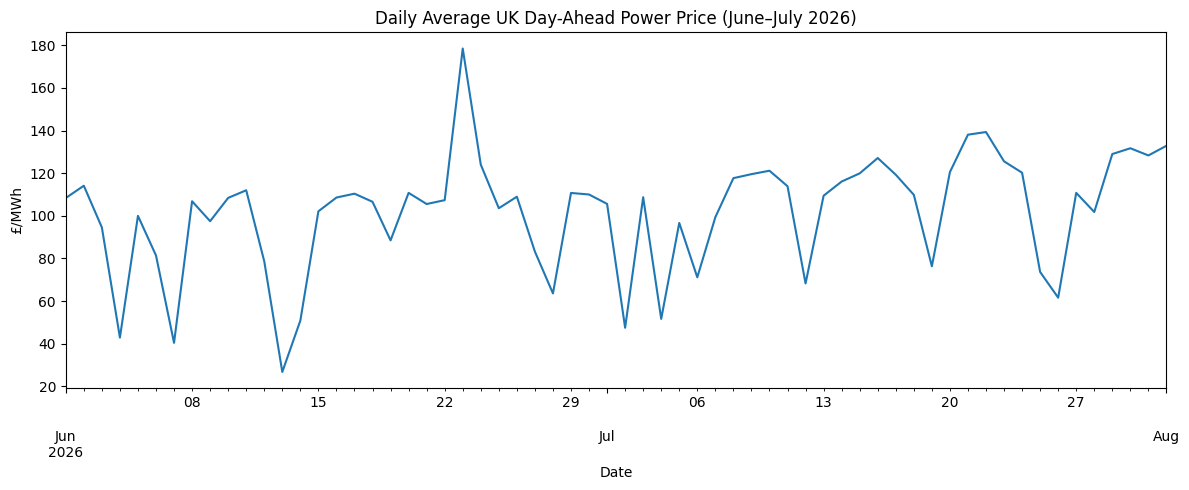

In [11]:
import matplotlib.pyplot as plt

# Collapse half-hourly data to daily averages for a readable trend chart
daily_price_full = merged_full["price"].resample("D").mean()

plt.figure(figsize=(12, 5))
daily_price_full.plot()
plt.title("Daily Average UK Day-Ahead Power Price (June–July 2026)")
plt.ylabel("£/MWh")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("daily_price.png", dpi=150)
plt.show()

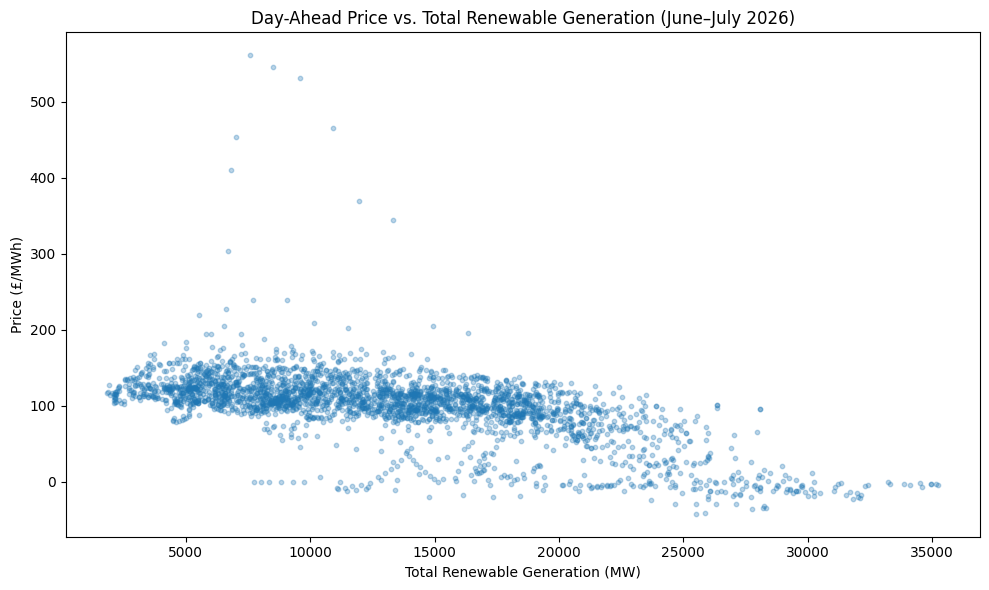

In [12]:
# alpha=0.3 makes overlapping points semi-transparent, so density is visible rather than a solid blob across ~2,900 points
plt.figure(figsize=(10, 6))
plt.scatter(merged_full["total_renewable_mw"], merged_full["price"], alpha=0.3, s=10)
plt.title("Day-Ahead Price vs. Total Renewable Generation (June–July 2026)")
plt.xlabel("Total Renewable Generation (MW)")
plt.ylabel("Price (£/MWh)")
plt.tight_layout()
plt.savefig("price_vs_renewables.png", dpi=150)
plt.show()

## 6. Investigating the highest prices of the period

Checks whether extreme prices coincide with unusually low renewable generation, and whether they're a general pattern or concentrated around a specific event.

In [13]:
# Check the actual highest price in the full dataset (not just one day) to test whether it coincides with unusually low renewable output
overall_max_row = merged_full.loc[merged_full["price"].idxmax()]
print(overall_max_row[["price", "total_renewable_mw", "is_peak"]])

price                 560.81
total_renewable_mw    7593.0
is_peak                 True
Name: 2026-06-23 19:30:00+00:00, dtype: object


In [14]:
# Look at the top 10 highest prices across the whole period (not just one day) to check whether extreme prices are a general pattern or concentrated around a specific event
top10 = merged_full.nlargest(10, "price")[["price", "total_renewable_mw", "is_peak"]]
top10["hour"] = top10.index.hour
top10["dayofweek"] = top10.index.dayofweek
top10

,price,total_renewable_mw,is_peak,hour,dayofweek
startTime,,,,,
2026-06-23 19:30:00+00:00,560.81,7593.0,True,19,1
2026-06-23 19:00:00+00:00,545.21,8506.0,True,19,1
2026-06-23 18:30:00+00:00,530.66,9581.0,True,18,1
2026-06-23 18:00:00+00:00,464.76,10915.0,True,18,1
2026-06-23 20:00:00+00:00,453.93,7007.0,False,20,1
2026-06-23 20:30:00+00:00,410.09,6827.0,False,20,1
2026-06-23 17:30:00+00:00,369.39,11957.0,True,17,1
2026-06-23 17:00:00+00:00,343.75,13311.0,True,17,1
2026-06-23 21:00:00+00:00,303.11,6692.0,False,21,1


In [15]:
merged_full["month"] = merged_full.index.month
monthly_vol = merged_full.groupby("month")["price"].std()
print(monthly_vol)

month
6    47.308699
7    40.685568
8          NaN
Name: price, dtype: float64


In [16]:
merged_full["date"] = merged_full.index.date
daily_vol = merged_full.groupby("date")["price"].std().sort_values(ascending=False)
daily_vol.head(10)

,price
date,
2026-06-23,137.295873
2026-07-25,62.907641
2026-07-26,62.786957
2026-06-28,62.195337
2026-06-07,54.093705
2026-07-19,52.706193
2026-07-12,50.901770
2026-07-04,50.497946
2026-07-27,46.308471


## 7. Volatility analysis

Uses standard deviation of price to quantify how much prices swung within a given period, and checks whether the extreme prices found above are part of a broader volatile month or concentrated on one day.

In [17]:
# Standard deviation of price by month - quantifies how much prices swung around their average, not just what the average was
merged_full["month"] = merged_full.index.month
monthly_vol = merged_full.groupby("month")["price"].std()
print(monthly_vol)

month
6    47.308699
7    40.685568
8          NaN
Name: price, dtype: float64


In [18]:
# Standard deviation of price by individual day - checks whether the extreme prices found above (23 June) reflect one unusually volatile day, or a broader volatile period
merged_full["date"] = merged_full.index.date
daily_vol = merged_full.groupby("date")["price"].std().sort_values(ascending=False)
daily_vol.head(10)

,price
date,
2026-06-23,137.295873
2026-07-25,62.907641
2026-07-26,62.786957
2026-06-28,62.195337
2026-06-07,54.093705
2026-07-19,52.706193
2026-07-12,50.901770
2026-07-04,50.497946
2026-07-27,46.308471
